In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
df = pd.read_csv(r"D:\datasets\telco_churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning

In [3]:
## Data Type

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
## Null value Check

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
## Show Null Value 

pd.to_numeric(df['TotalCharges'], errors='coerce').isnull().sum()

np.int64(11)

In [6]:
## Describe Null Value 

df[pd.to_numeric(df['TotalCharges'],errors='coerce').isnull()][['tenure','MonthlyCharges','TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


In [7]:
## Clean Null Value into float with fill o

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['TotalCharges'].dtype

dtype('float64')

In [8]:
## Churn Distribution 

df['Churn'].value_counts()


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:

## Percentaage value

df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

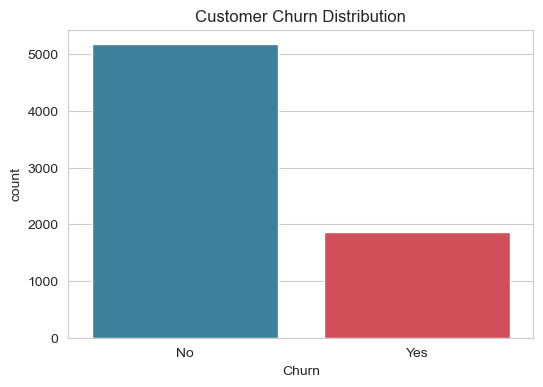

In [10]:
## Churn Distribution Graph

fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=df, x='Churn',hue='Churn',palette=['#2E86Ab','#E63946'],legend=False,ax=ax)
ax.set_title('Customer Churn Distribution')
plt.show()

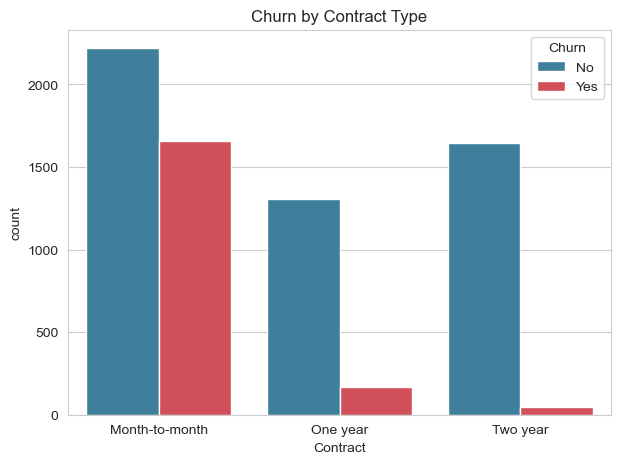

In [11]:
## Churn vs Contract Type

fig, ax = plt.subplots(figsize=(7,5))
sns.countplot(data=df,x='Contract',hue='Churn',palette=['#2E86AB','#E63946'], ax = ax)
ax.set_title("Churn by Contract Type")
plt.show()

In [12]:
## Churn % per Contract Type

df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64

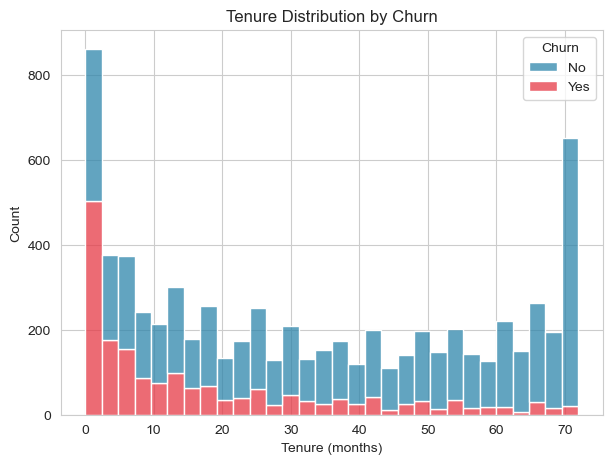

In [13]:
## Churn vs Tenure

fig, ax = plt.subplots(figsize=(7,5))
sns.histplot(data=df, x='tenure',hue='Churn',multiple='stack',bins=30,palette=['#2E86AB','#E63946'])
ax.set_title('Tenure Distribution by Churn')
ax.set_xlabel('Tenure (months)')
plt.show()

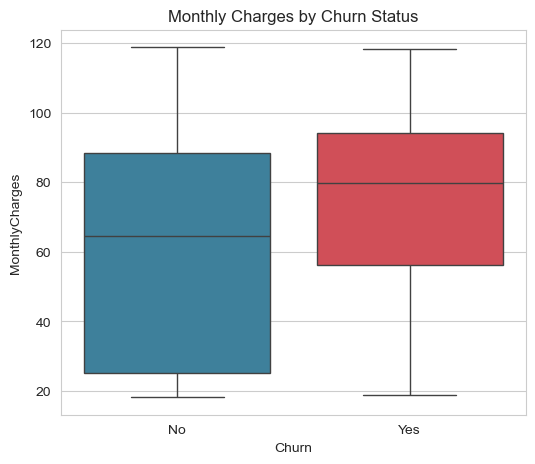

In [14]:
## Monthly Charges vs Churn

fix, ax = plt.subplots(figsize=(6,5))
sns.boxplot(data=df, x = 'Churn', y = 'MonthlyCharges',hue='Churn',palette=['#2E86AB','#E63946'],legend=False,ax = ax)
ax.set_title('Monthly Charges by Churn Status')
plt.show()

In [15]:
## Data Cleaning by map() 
## convert data into str to num (ml not understand str onlt understand numbers)

df['Churn'] = df['Churn'].map({'Yes' : 1, 'No' : 0})
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [16]:
## Convert Text into Number

categorical_cols = df.drop(columns=['customerID','Churn']).select_dtypes(include='object').columns.tolist()
print(categorical_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [17]:
## Encoding the code 

df_model = df.drop(columns=['customerID'])
df_encoded = pd.get_dummies(df_model, columns = categorical_cols,drop_first = True)
print("First Shape :", df_model.shape)
print("Encoding Shape:", df_encoded.shape)
df_encoded.head()

First Shape : (7043, 20)
Encoding Shape: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [18]:
## Train/Test Split

from sklearn.model_selection import train_test_split

x = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=42, stratify=y)

print("Train Size:", x_train.shape)
print("Test Size:", x_test.shape)

Train Size: (5634, 30)
Test Size: (1409, 30)


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(x_train, y_train)

y_pred = log_reg.predict(x_test)
y_prob = log_reg.predict_proba(x_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8422408225477278


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
## Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['tenure','MonthlyCharges','TotalCharges']

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()
x_train_scaled[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test_scaled[num_cols] = scaler.transform(x_test[num_cols])

x_train_scaled[num_cols].head()

,tenure,MonthlyCharges,TotalCharges
3738,0.102371,-0.521976,-0.262257
3151,-0.711743,0.337478,-0.503635
4860,-0.793155,-0.809013,-0.749883
3867,-0.263980,0.284384,-0.172722
3810,-1.281624,-0.676279,-0.989374


In [27]:
## Feature Scaling

log_reg = LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42)
log_reg.fit(x_train_scaled, y_train)

y_pred_lr = log_reg.predict(x_test_scaled)
y_prob_lr = log_reg.predict_proba(x_test_scaled)[:,1]

print(classification_report(y_test,y_pred_lr,target_names=['No Churn','Churn']))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8417318969748638


In [28]:
## Random Forest Model

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',random_state=42,n_jobs=-1)
rf.fit(x_train,y_train)

y_pred_rf = rf.predict(x_test)
y_prob_rf = rf.predict_proba(x_test)[:,1]

print(classification_report(y_test, y_pred_rf,target_names=['No Churn','Churn']))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

    No Churn       0.91      0.75      0.82      1035
       Churn       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409

ROC-AUC: 0.8436784727066057


In [29]:
## XG Boost

from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate = 0.05,scale_pos_weight = scale_pos_weight, eval_metric='logloss',random_state=42)

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)
y_prob_xgb = xgb.predict_proba(x_test)[:,1]

print(classification_report(y_test, y_pred_xgb, target_names=['No Churn','Churn']))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))



              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.838821721046785


In [30]:
## Model Comparison Table

results = {
    'Logistic Regression': {'recall': 0.78, 'precision': 0.50, 'roc_auc': 0.842},
    'Random Forest': {'recall': 0.78, 'precision': 0.53, 'roc_auc': 0.844},
    'XGBoost': {'recall': 0.79, 'precision': 0.52, 'roc_auc': 0.839}
}
results_df = pd.DataFrame(results).T
results_df

,recall,precision,roc_auc
Logistic Regression,0.78,0.50,0.842
Random Forest,0.78,0.53,0.844
XGBoost,0.79,0.52,0.839


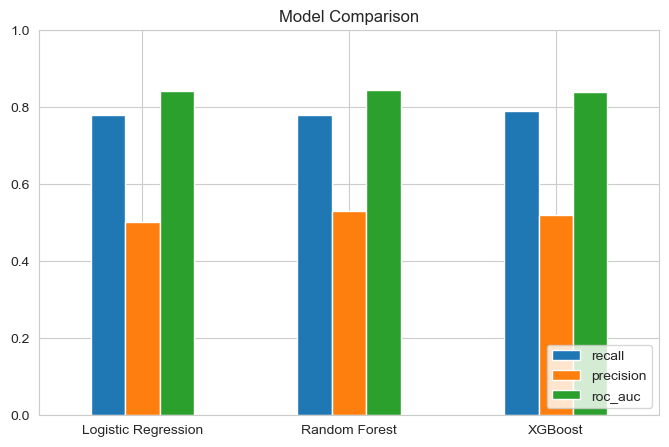

In [31]:
## Comparison Graph

fig, ax = plt.subplots(figsize=(8,5))
results_df.plot(kind='bar', ax=ax)
ax.set_title('Model Comparison')
ax.set_ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()


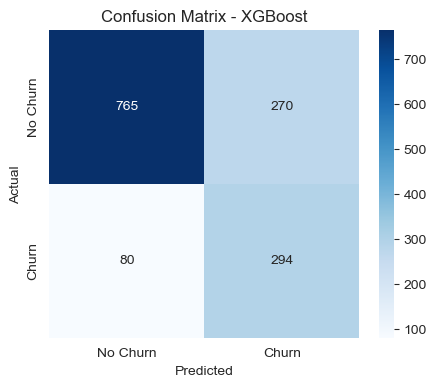

Correctly caught churners (True Positive): 294
Missed churners (False Negative): 80
False alarms (False Positive): 270
Correctly identified non-churners (True Negative): 765


In [32]:
##  Confusion Matrix (XGBoost)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - XGBoost')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Correctly caught churners (True Positive): {tp}")
print(f"Missed churners (False Negative): {fn}")
print(f"False alarms (False Positive): {fp}")
print(f"Correctly identified non-churners (True Negative): {tn}")

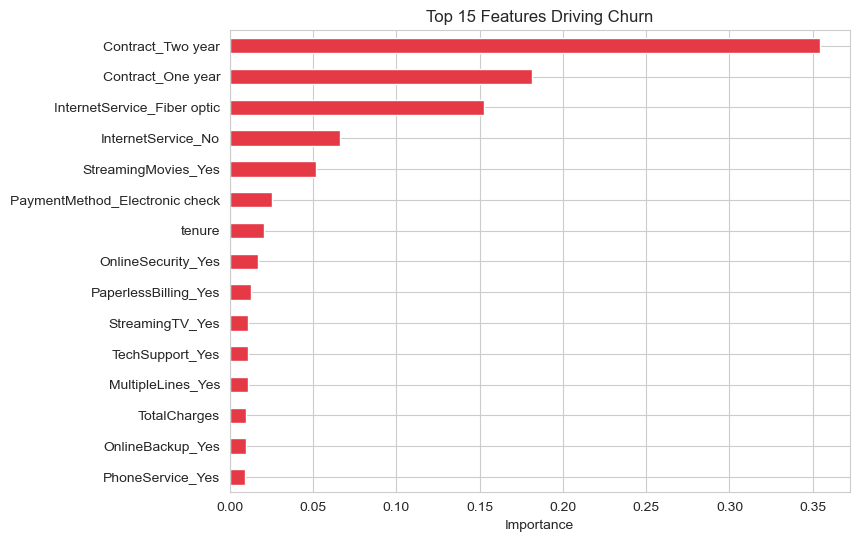

Contract_Two year                 0.354532
Contract_One year                 0.181580
InternetService_Fiber optic       0.152307
InternetService_No                0.066216
StreamingMovies_Yes               0.051874
PaymentMethod_Electronic check    0.025516
tenure                            0.020735
OnlineSecurity_Yes                0.016733
PaperlessBilling_Yes              0.012780
StreamingTV_Yes                   0.010961
TechSupport_Yes                   0.010713
MultipleLines_Yes                 0.010666
TotalCharges                      0.009992
OnlineBackup_Yes                  0.009928
PhoneService_Yes                  0.009250
dtype: float32

In [34]:
## Feature Importance

importances = pd.Series(xgb.feature_importances_, index=x_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8,6))
top_features.sort_values().plot(kind='barh', ax=ax, color='#E63946')
ax.set_title('Top 15 Features Driving Churn')
ax.set_xlabel('Importance')
plt.show()

top_features

In [36]:
import joblib

joblib.dump(xgb, 'churn_model.pkl')
joblib.dump(list(x_train.columns), 'model_columns.pkl')

print("Model saved!")

Model saved!


In [38]:
import os
print(os.getcwd())

C:\Users\HP\Desktop\churn_project\data
